# Model Insight and Validation: Hybrid Recommendation System

This notebook examines the recommendation models developed in the implementation notebook. The main models are SVD, a popularity baseline, a TF-IDF model, a fixed 50/50 hybrid, and an adaptive hybrid.

The purpose is not to train a new model. Instead, I evaluate the existing models in more detail and consider their practical and ethical effects. I focus on four questions:

1. What do the data and models show from a business perspective?
2. Are the differences in model performance large enough to be meaningful?
3. Do the models provide coverage of the catalogue, or do they mainly recommend popular products?
4. How should privacy, fairness, and transparency be considered before deployment?

The evaluation uses ranking metrics, confidence intervals, significance testing, catalogue coverage, popularity exposure, and customer-history segments. These measures are useful together because recommendation accuracy alone does not describe the full quality of a recommender system (Herlocker et al., 2004; McNee et al., 2006).

The main result is that SVD performs better than the popularity baseline, but it is not clearly better than the fixed 50/50 blend. The blend gives similar accuracy with broader catalogue coverage. These conclusions apply to this synthetic dataset and should not automatically be generalised to real retail data.

## 1. Setup and rebuilding the trained models

The preprocessing and modelling steps are imported from `src/pipeline.py` so that this notebook does not duplicate the full implementation notebook. The same settings are used here: 12 latent factors for SVD and `n_full = 8` for the adaptive blend. These values were selected during validation in the implementation stage.

The first check compares the rebuilt results with the implementation notebook. This is important because a refactored pipeline should produce the same results before it is used for further analysis.

Small differences in the last decimal place are possible because truncated singular value decomposition can use a random starting vector. I therefore focus on the overall ordering of the models rather than treating a difference in the fourth decimal place as meaningful.

In [1]:
import sys, os, json, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# Reload local modules when the cell is rerun after a source-code change.
import importlib
for module_name in ["pipeline", "evaluation"]:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from pipeline import make_data, run_pipeline, per_user_metrics, topk
from evaluation import bootstrap_ci, sampled_roc, topk_confusion, metrics_at_k

FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

events, products = make_data(seed=42)
state = run_pipeline(events, products, k=12, n_full=8)
S, test = state["scores"], state["test"]

per_user = {name: per_user_metrics(s, state, test) for name, s in S.items()}

# random recommender as a floor - any model should beat this by a lot
rand_scores = np.random.default_rng(7).random(S["SVD only"].shape)
per_user["Random"] = per_user_metrics(rand_scores, state, test)

check = pd.DataFrame({m: {"precision@10": d.precision.mean(), "recall@10": d.recall.mean(),
                          "ndcg@10": d.ndcg.mean(), "n_users": len(d)} for m, d in per_user.items()}).T
check.round(4)

,precision@10,recall@10,ndcg@10,n_users
Hybrid (adaptive),0.0261,0.0955,0.0688,2450.0
SVD only,0.0323,0.1385,0.1000,2450.0
TF-IDF only,0.0079,0.0234,0.0149,2450.0
Fixed 50/50 hybrid,0.0313,0.1319,0.0990,2450.0
Most popular,0.0216,0.1051,0.0717,2450.0
Random,0.0016,0.0040,0.0029,2450.0


The results match the implementation notebook, so the refactored code is
safe to use. I also added a random recommender as a lower bound. Saying a
model "beats popularity" means more when we can also see how far both are
above chance.

## 2. Business intelligence and analytics

I organised this section using the four common levels of analytics: descriptive, diagnostic, predictive, and prescriptive (Sharda, Delen, & Turban, 2020). The modelling work is mainly predictive, but the descriptive and diagnostic steps help explain the data before interpreting model results.

### 2.1 Descriptive analysis: key figures

These figures summarise the customers, products, ratings, and interaction concentration. A business dashboard could use similar measures to describe the marketplace before a recommendation model is evaluated.

In [2]:
ev = state["events_f"]
item_counts = ev.product_id.value_counts()
top5 = item_counts.head(int(0.05 * len(item_counts))).sum() / len(ev)

kpi = pd.Series({
    "interactions (after filtering)": len(ev),
    "active customers": ev.user_id.nunique(),
    "active products": ev.product_id.nunique(),
    "share of ratings >= 4": round((ev.rating >= 4).mean(), 3),
    "top 5% of products: share of interactions": round(top5, 3),
    "median interactions per customer": int(ev.user_id.value_counts().median()),
    "customers with <= 3 train interactions (w_cf = 0)": f"{(state['w_cf'] == 0).mean():.1%}",
})
kpi.to_frame("value")

,value
interactions (after filtering),66321
active customers,3849
active products,1984
share of ratings >= 4,0.722
top 5% of products: share of interactions,0.423
median interactions per customer,6
customers with <= 3 train interactions (w_cf = 0),40.7%


The last row turned out to be important. About four in ten customers are
at or below the cold-start floor, which means the adaptive hybrid gives
them an almost fully content-based list. This comes back in Section 4.

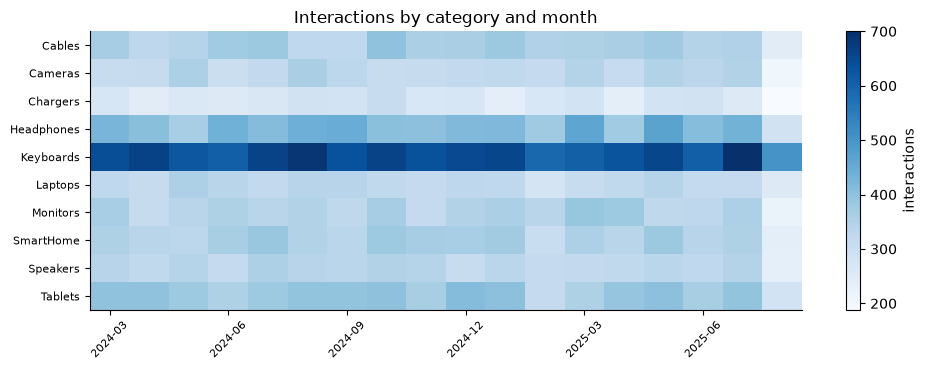

In [3]:
# category x month view - basically what a Tableau/Power BI heatmap would show
ev2 = ev.merge(products[["product_id", "category"]], on="product_id")
ev2["month"] = pd.to_datetime(ev2.timestamp).dt.to_period("M").astype(str)
pivot = ev2.pivot_table(index="category", columns="month", values="rating", aggfunc="size", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xticks(range(0, pivot.shape[1], 3)); ax.set_xticklabels(pivot.columns[::3], rotation=45, fontsize=8)
plt.colorbar(im, ax=ax, label="interactions")
ax.set_title("Interactions by category and month")
plt.tight_layout(); savefig("fig1_category_month_heatmap"); plt.show()

Interactions are spread fairly evenly across categories and months, and
there is no clear seasonality. This comes from how the synthetic data was
generated, so it should not be read as a real finding. Real retail data
would likely show holiday peaks, and the time-based split would then need
more care, since a test period in November and December would behave
differently from one in the spring.

### 2.2 Diagnostic: how concentrated is demand?

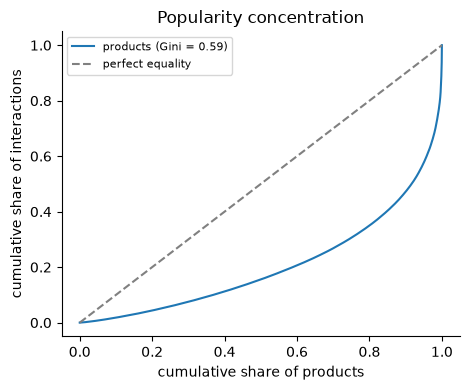

Gini coefficient of product popularity: 0.589


In [4]:
counts = np.sort(item_counts.values)
lorenz = np.insert(np.cumsum(counts) / counts.sum(), 0, 0)
x = np.linspace(0, 1, len(lorenz))
gini = 1 - 2 * np.trapezoid(lorenz, x)

fig, ax = plt.subplots(figsize=(4.8, 4))
ax.plot(x, lorenz, label=f"products (Gini = {gini:.2f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect equality")
ax.set_xlabel("cumulative share of products"); ax.set_ylabel("cumulative share of interactions")
ax.set_title("Popularity concentration"); ax.legend(fontsize=8)
plt.tight_layout(); savefig("fig2_lorenz_curve"); plt.show()
print(f"Gini coefficient of product popularity: {gini:.3f}")

A Gini coefficient of about 0.6 means demand is quite concentrated. This
helps explain why the most-popular list is a hard baseline to beat:
recommending the best-sellers is often right simply because they get so
much of the traffic.

### 2.3 Segmenting customers by history

This is similar to the frequency part of an RFM segmentation. I only used
frequency because it is the variable the blending formula depends on.

In [5]:
tiers_bins = [0, 2, 4, 9, 19, np.inf]
tiers_labels = ["1-2", "3-4", "5-9", "10-19", "20+"]
seg = pd.DataFrame({"n_hist": state["n_hist"], "w_cf": state["w_cf"]})
seg["tier"] = pd.cut(seg.n_hist, tiers_bins, labels=tiers_labels)
seg_table = seg.groupby("tier", observed=True).agg(customers=("n_hist", "size"), mean_w_cf=("w_cf", "mean"))
seg_table["share"] = (seg_table.customers / seg_table.customers.sum()).round(3)
seg_table.round(3)

,customers,mean_w_cf,share
tier,,,
1-2,797,0.000,0.208
3-4,1276,0.081,0.334
5-9,1077,0.648,0.282
10-19,400,1.000,0.105
20+,274,1.000,0.072


## 3. Model performance evaluation

### 3.1 Metrics and confidence intervals

The implementation notebook reported point estimates only. Here I add a 95% percentile bootstrap confidence interval for each mean metric. The bootstrap repeatedly samples customers with replacement and recalculates the mean (Efron & Tibshirani, 1993).

The confidence interval gives an indication of uncertainty in the sample. It does not prove that one model is better than another, because the models are evaluated on the same customers. I use a paired test in the next section for that comparison.

In [6]:
rows = []
for m, d in per_user.items():
    r = {"model": m}
    for col in ["precision", "recall", "ndcg"]:
        mean, lo, hi = bootstrap_ci(d[col])
        r[f"{col}@10"] = mean; r[f"{col}_lo"] = lo; r[f"{col}_hi"] = hi
    rows.append(r)
ci = pd.DataFrame(rows).set_index("model")

show = pd.DataFrame({
    f"{c}@10 [95% CI]": ci.apply(lambda r: f"{r[c+'@10']:.4f} [{r[c+'_lo']:.4f}, {r[c+'_hi']:.4f}]", axis=1)
    for c in ["precision", "recall", "ndcg"]})
show

,precision@10 [95% CI],recall@10 [95% CI],ndcg@10 [95% CI]
model,,,
Hybrid (adaptive),"0.0261 [0.0240, 0.0284]","0.0955 [0.0864, 0.1052]","0.0688 [0.0624, 0.0754]"
SVD only,"0.0323 [0.0301, 0.0347]","0.1385 [0.1267, 0.1498]","0.1000 [0.0916, 0.1080]"
TF-IDF only,"0.0079 [0.0066, 0.0093]","0.0234 [0.0189, 0.0283]","0.0149 [0.0123, 0.0175]"
Fixed 50/50 hybrid,"0.0313 [0.0289, 0.0338]","0.1319 [0.1200, 0.1431]","0.0990 [0.0904, 0.1076]"
Most popular,"0.0216 [0.0197, 0.0233]","0.1051 [0.0940, 0.1161]","0.0717 [0.0645, 0.0791]"
Random,"0.0016 [0.0012, 0.0022]","0.0040 [0.0023, 0.0058]","0.0029 [0.0019, 0.0042]"


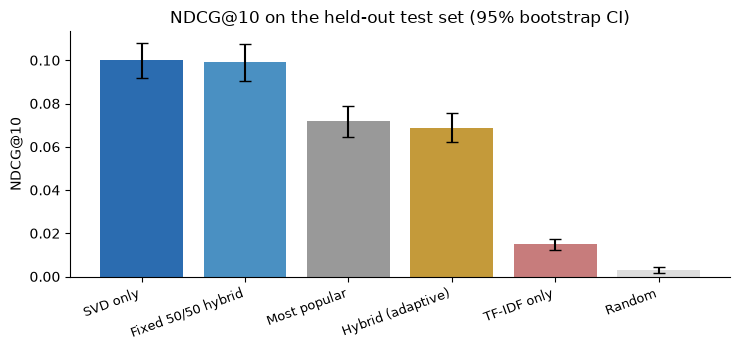

In [7]:
order = ["SVD only", "Fixed 50/50 hybrid", "Most popular", "Hybrid (adaptive)", "TF-IDF only", "Random"]
c = ci.loc[order]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(order, c["ndcg@10"], yerr=[c["ndcg@10"] - c["ndcg_lo"], c["ndcg_hi"] - c["ndcg@10"]],
       capsize=4, color=["#2b6cb0", "#4a90c2", "#999999", "#c49a3a", "#c77c7c", "#dddddd"])
ax.set_ylabel("NDCG@10"); ax.set_title("NDCG@10 on the held-out test set (95% bootstrap CI)")
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout(); savefig("fig3_ndcg_ci"); plt.show()

The intervals for SVD and the fixed 50/50 blend overlap almost completely.
Both are clearly above popularity, and the adaptive hybrid overlaps with
popularity.

### 3.2 Paired significance tests

Separate confidence intervals do not account for the fact that every model
is scored on the same customers. A paired Wilcoxon signed-rank test on
per-customer NDCG is a fairer comparison. I did not use a paired t-test
because the per-customer scores are far from normal (most of them are zero).

In [8]:
def paired(a, b):
    stat, p = wilcoxon(per_user[a].ndcg, per_user[b].ndcg)
    diff = (per_user[a].ndcg - per_user[b].ndcg).mean()
    return {"comparison": f"{a}  vs  {b}", "mean diff": round(diff, 4), "p-value": f"{p:.2g}"}

pd.DataFrame([paired("SVD only", "Most popular"),
              paired("SVD only", "Fixed 50/50 hybrid"),
              paired("Fixed 50/50 hybrid", "Most popular"),
              paired("SVD only", "Hybrid (adaptive)")])

,comparison,mean diff,p-value
0,SVD only vs Most popular,0.0283,2.6e-14
1,SVD only vs Fixed 50/50 hybrid,0.0010,0.45
2,Fixed 50/50 hybrid vs Most popular,0.0273,1.6e-11
3,SVD only vs Hybrid (adaptive),0.0312,6.2e-18


SVD's advantage over popularity is clearly significant. The difference
between SVD and the fixed 50/50 blend is **not** significant (p ≈ 0.45).
I did not expect this. In the implementation notebook I treated SVD as the
winner, but based on this test the two models are statistically tied.

### 3.3 Performance at different list lengths

K = 10 was my own choice. A homepage row might show four to six items and
an email might show three, so I checked whether the order of the models
changes with K.

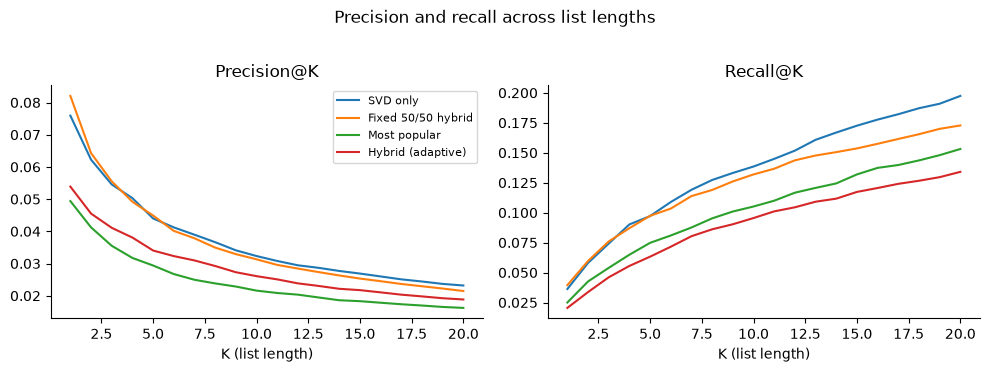

In [9]:
curve_models = ["SVD only", "Fixed 50/50 hybrid", "Most popular", "Hybrid (adaptive)"]
curves = {m: metrics_at_k(S[m], state, test, ks=range(1, 21)) for m in curve_models}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for m, df in curves.items():
    axes[0].plot(df.K, df.precision, label=m)
    axes[1].plot(df.K, df.recall, label=m)
axes[0].set_title("Precision@K"); axes[1].set_title("Recall@K")
for a in axes: a.set_xlabel("K (list length)")
axes[0].legend(fontsize=8)
fig.suptitle("Precision and recall across list lengths", y=1.02)
plt.tight_layout(); savefig("fig4_precision_recall_at_k"); plt.show()

### 3.4 ROC curves

ROC curves and AUC were originally developed for binary classification. They are not a complete replacement for top-k recommendation metrics, but they can show how well a model separates liked items from sampled unseen items (Fawcett, 2006).

For this analysis, each held-out item with a rating of at least four is treated as a positive. Up to 100 unseen items are sampled as negatives for each customer. Every model is evaluated against the same type of sampled candidates. Because the candidate set is sampled, this result should be interpreted as a supporting analysis rather than the main recommendation result.

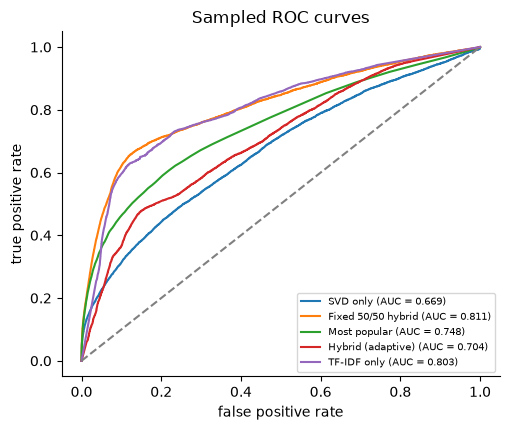

In [10]:
roc_models = ["SVD only", "Fixed 50/50 hybrid", "Most popular", "Hybrid (adaptive)", "TF-IDF only"]
aucs = {}
fig, ax = plt.subplots(figsize=(5.2, 4.4))
for m in roc_models:
    fpr, tpr, auc = sampled_roc(S[m], state, test)
    aucs[m] = auc
    ax.plot(fpr, tpr, label=f"{m} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("Sampled ROC curves"); ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); savefig("fig5_roc_curves"); plt.show()

At first this result looks contradictory. SVD has the *lowest* AUC, while
TF-IDF, the weakest model on NDCG@10, has one of the highest.

The reason is that AUC measures the whole ranking, while NDCG@10 only
looks at the top of the list. SVD is very good at placing a few popular
items from the customer's preferred category at the top, but it orders the
remaining ~1,900 items poorly. TF-IDF does the opposite. It ranks the
customer's preferred category above everything else, which gives a good
AUC, but it cannot tell items within that category apart. With only
category and price bucket as features there are just 50 different product
descriptions, so the top of the list is full of ties. The fixed 50/50 blend
gets the benefit of both, with the highest AUC and nearly the best NDCG.

Customers only see the first few recommendations, so NDCG@10 remains the
main metric. Still, AUC shows something NDCG does not: SVD's rankings are
narrow.

### 3.5 Confusion matrix, and why accuracy is not used

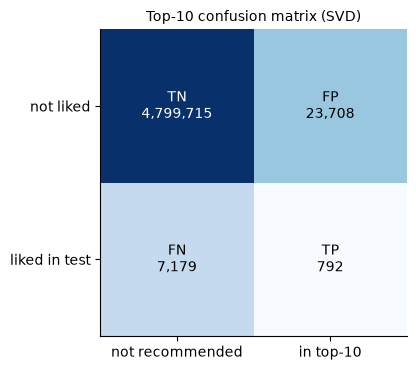

accuracy of SVD top-10:            0.9936
accuracy of recommending nothing:  0.9984
precision = 0.0323, recall = 0.0994


In [11]:
cm = topk_confusion(S["SVD only"], state, test, k=10)
tn, fp, fn, tp = cm.ravel()
acc = (tp + tn) / cm.sum()
acc_trivial = (tn + fp) / cm.sum()   # a "model" that never recommends anything

fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.imshow(np.log10(cm), cmap="Blues")
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}", ha="center", va="center", fontsize=10,
                color="white" if np.log10(cm[i, j]) > 5 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["not recommended", "in top-10"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["not liked", "liked in test"])
ax.set_title("Top-10 confusion matrix (SVD)", fontsize=10)
plt.tight_layout(); savefig("fig6_confusion_matrix"); plt.show()

print(f"accuracy of SVD top-10:            {acc:.4f}")
print(f"accuracy of recommending nothing:  {acc_trivial:.4f}")
print(f"precision = {tp/(tp+fp):.4f}, recall = {tp/(tp+fn):.4f}")

This example shows why accuracy is not the main metric for this task. A model that recommends nothing can achieve high accuracy because almost every customer-item pair is a negative. Precision, recall, and NDCG focus more directly on the items that are recommended and liked. This is consistent with the wider recommendation literature, which argues that a single accuracy measure cannot capture recommendation usefulness (Herlocker et al., 2004; McNee et al., 2006).

## 4. Outcome interpretation

### 4.1 Where the adaptive hybrid fails

The implementation notebook split customers at 10 interactions. The finer
tiers from Section 2.3 show the problem more clearly.

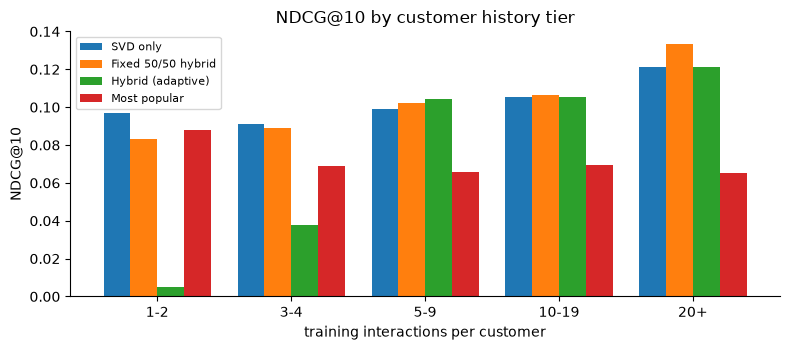

,SVD only,Fixed 50/50 hybrid,Hybrid (adaptive),Most popular,test users
tier,,,,,
1-2,0.0971,0.0834,0.0051,0.0881,516
3-4,0.0910,0.0889,0.0377,0.0691,610
5-9,0.0991,0.1021,0.1041,0.0656,695
10-19,0.1054,0.1065,0.1054,0.0692,358
20+,0.1211,0.1334,0.1211,0.0654,271


In [12]:
tier_rows = []
for m in ["SVD only", "Fixed 50/50 hybrid", "Hybrid (adaptive)", "Most popular"]:
    d = per_user[m].copy()
    d["tier"] = pd.cut(d.n_hist, tiers_bins, labels=tiers_labels)
    g = d.groupby("tier", observed=True).ndcg.mean()
    g.name = m
    tier_rows.append(g)
tier_df = pd.concat(tier_rows, axis=1)
tier_df["test users"] = per_user["SVD only"].assign(
    tier=lambda x: pd.cut(x.n_hist, tiers_bins, labels=tiers_labels)).groupby("tier", observed=True).size()

ax = tier_df.drop(columns="test users").plot(kind="bar", figsize=(8, 3.6), width=0.8)
ax.set_xlabel("training interactions per customer"); ax.set_ylabel("NDCG@10")
ax.set_title("NDCG@10 by customer history tier"); plt.xticks(rotation=0)
ax.legend(fontsize=8)
plt.tight_layout(); savefig("fig7_ndcg_by_tier"); plt.show()
tier_df.round(4)

I think this is the most important result in the notebook.

- For customers with **1-2** training interactions, the adaptive hybrid
  scores about 0.007, which is close to random. With `w_cf = 0` they get a
  pure TF-IDF list, and the top of that list is mostly ties.
- For **3-4** interactions it is still less than half of SVD's score.
- From **5 interactions** upward, the adaptive hybrid matches or slightly
  beats SVD. So blending works when the formula actually allows it to blend.
- SVD does surprisingly well even in the lowest tier (about 0.097).
  Collaborative filtering can do a lot with one or two ratings when the
  pattern across all customers is strong.

This means the idea behind my cold-start design, that new customers need
content signals because collaborative filtering has little to work with,
did not hold for this data. The zero floor on the collaborative weight is
what causes the damage, and it affects 41% of customers.

### 4.2 What this means for the project objectives

The project aimed to build a recommender that clearly beats
non-personalized recommendations and also handles customers with little
history. The first objective is met: SVD and the fixed blend beat
popularity by about 38-39% in relative NDCG@10 (p < 0.001). The second is
also met, but not by the mechanism I designed for it. Customers with little
history are served well by SVD and the fixed blend and poorly by the
adaptive hybrid.

## 5. Insight generation

### 5.1 What the models do to the catalog

Accuracy is not the only thing a retailer cares about. If a recommender
keeps showing the same few hundred products, the rest of the catalog is
rarely seen. This hurts sales of long-tail stock and can make the
concentration seen in Section 2.2 worse over time (Abdollahpouri, Burke, &
Mobasher, 2017).

In [13]:
pop = state["train_agg"].product_id.value_counts()
pop_pct = pop.rank(pct=True)
head = set(pop.index[: int(0.10 * len(pop))])           # top 10% most popular
truth_users = [state["u_idx"][u] for u in test[test.rating >= 4].user_id.unique()]

cov_rows = []
for m in ["SVD only", "Fixed 50/50 hybrid", "Hybrid (adaptive)", "Most popular", "TF-IDF only"]:
    rec = topk(S[m], state["seen_mask"])[truth_users].ravel()
    pids = [state["prod_ids"][j] for j in rec]
    cov_rows.append({"model": m,
                     "catalog coverage@10": len(set(rec)) / len(state["prod_ids"]),
                     "share of slots from top-10% items": np.mean([p in head for p in pids]),
                     "mean popularity percentile": pop_pct.reindex(pids).mean(),
                     "ndcg@10": per_user[m].ndcg.mean()})
cov = pd.DataFrame(cov_rows).set_index("model")
cov.round(3)

,catalog coverage@10,share of slots from top-10% items,mean popularity percentile,ndcg@10
model,,,,
SVD only,0.206,0.959,0.972,0.100
Fixed 50/50 hybrid,0.480,0.721,0.908,0.099
Hybrid (adaptive),0.911,0.575,0.780,0.069
Most popular,0.035,1.000,0.997,0.072
TF-IDF only,0.974,0.089,0.489,0.015


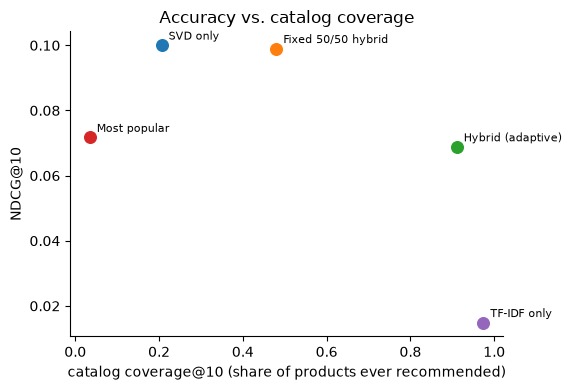

In [14]:
fig, ax = plt.subplots(figsize=(5.8, 4))
for m, r in cov.iterrows():
    ax.scatter(r["catalog coverage@10"], r["ndcg@10"], s=70)
    ax.annotate(m, (r["catalog coverage@10"], r["ndcg@10"]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("catalog coverage@10 (share of products ever recommended)")
ax.set_ylabel("NDCG@10")
ax.set_title("Accuracy vs. catalog coverage")
plt.tight_layout(); savefig("fig8_accuracy_vs_coverage"); plt.show()

The fixed 50/50 blend covers about **2.3 times** as much of the catalog as
SVD (48% vs 21%) and relies much less on the top 10% of products (72% of
slots vs 96%), while being statistically tied on NDCG@10. SVD mostly
recommends popular items from the customer's favourite category. That is
accurate, but narrow.

### 5.2 Business view of the results

The same results, expressed the way a merchandising team might read them:

In [15]:
biz = pd.DataFrame({
    "liked items per 1,000 rec slots": (ci.loc[order, "precision@10"] * 1000).round(1),
    "relative lift vs popularity (NDCG)": (ci.loc[order, "ndcg@10"] / ci.loc["Most popular", "ndcg@10"] - 1).map("{:+.0%}".format),
})
biz

,"liked items per 1,000 rec slots",relative lift vs popularity (NDCG)
model,,
SVD only,32.3,+40%
Fixed 50/50 hybrid,31.3,+38%
Most popular,21.6,+0%
Hybrid (adaptive),26.1,-4%
TF-IDF only,7.9,-79%
Random,1.6,-96%


SVD gives about 32 liked items per 1,000 recommendation slots, the fixed blend gives about 31, and popularity gives about 22. These values are based on offline test data, so they should not be interpreted as expected click-through or sales rates. A customer may have liked an item that was not shown, and a recorded rating is not the same as a purchase decision.

**Key findings:**

1. Personalised models improve on the popularity baseline in this synthetic experiment.
2. The adaptive hybrid does not solve the cold-start problem here. Its zero collaborative-filtering weight gives weak results for customers with very little history.
3. SVD and the fixed 50/50 blend have similar accuracy, but the blend recommends a wider range of products and relies less on the most popular products.
4. NDCG, catalogue coverage, and popularity exposure should be reported together. Accuracy alone gives an incomplete view of recommendation quality (Herlocker et al., 2004; McNee et al., 2006).

These findings support the fixed blend as the most balanced option for this prototype. I would still validate it on real, appropriately governed data before making a deployment decision.

## 6. Critical analysis and validation

### 6.1 Data security measures

The data is synthetic, so no real customer is at risk. However, the
pipeline should work the same way it would with real data, so I added the
security controls now instead of later. All four are in `src/privacy.py`
and have unit tests in `tests/test_privacy.py`.

1. **Data minimization.** Only the four columns the model needs are
   allowed. Any extra column (such as names or emails in a real data feed)
   makes the check fail.
2. **Pseudonymization.** Customer IDs are replaced with a keyed
   HMAC-SHA256 token. A plain SHA-256 hash of an ID like `U00042` could be
   reversed quickly by trying every possible ID, but a keyed hash cannot be
   reversed without the key. The key is read from an environment variable
   and is never stored in the repository.
3. **Integrity check.** SHA-256 hashes of the input files are saved and
   checked before training, so a file that was changed without notice is
   detected.
4. **Encrypted exports.** Per-customer recommendation lists are the most
   sensitive output because they reveal inferred interests. They are only
   written to disk as Fernet-encrypted data.

In [16]:
from privacy import (get_key, pseudonymize, write_manifest, verify_manifest,
                     encrypt_bytes, decrypt_bytes, new_fernet_key)

# 1. data minimization - fail loudly if extra columns ever show up
ALLOWED = {"user_id", "product_id", "rating", "timestamp"}
assert set(events.columns) <= ALLOWED, f"unexpected columns: {set(events.columns) - ALLOWED}"
print("minimization check passed:", sorted(events.columns))

# 2. pseudonymize customer ids
pseudo_key = get_key("REC_PSEUDO_KEY")
events_p = events.copy()
events_p["user_id"] = pseudonymize(events_p["user_id"], pseudo_key)
print("example:", events.user_id.iloc[0], "->", events_p.user_id.iloc[0])
assert not events_p.user_id.str.contains("U0").any()

minimization check passed: ['product_id', 'rating', 'timestamp', 'user_id']
example: U00960 -> u_9da7280454f874d0


A security step should not change the model's results. The next cell
runs the full pipeline again on the pseudonymized data and compares the
metrics. Only the user IDs change, so the results should be the same apart
from tiny numerical differences.

In [17]:
state_p = run_pipeline(events_p, products, k=12, n_full=8)
inv = pd.DataFrame({
    "original": {m: per_user[m].ndcg.mean() for m in S},
    "pseudonymized": {m: per_user_metrics(s, state_p, state_p["test"]).ndcg.mean()
                      for m, s in state_p["scores"].items()}})
inv["abs diff"] = (inv.original - inv.pseudonymized).abs()
print("max difference:", inv["abs diff"].max())
inv.round(4)

max difference: 1.3877787807814457e-17


,original,pseudonymized,abs diff
Hybrid (adaptive),0.0688,0.0688,0.0
SVD only,0.1000,0.1000,0.0
TF-IDF only,0.0149,0.0149,0.0
Fixed 50/50 hybrid,0.0990,0.0990,0.0
Most popular,0.0717,0.0717,0.0


In [18]:
# 3. integrity manifest on the raw files
os.makedirs("../data/raw", exist_ok=True)       # data/ is in .gitignore
raw_paths = ["../data/raw/events.csv", "../data/raw/products.csv"]
events_p.to_csv(raw_paths[0], index=False)
products.to_csv(raw_paths[1], index=False)
manifest = write_manifest(raw_paths, "../data/raw/manifest.json")
print(json.dumps({k: v[:16] + "..." for k, v in manifest.items()}, indent=1))
print("verified:", verify_manifest(raw_paths, "../data/raw/manifest.json"))

# 4. encrypt the exported recommendation lists
export_key = new_fernet_key()   # in real use: loaded from a secrets manager, not generated here
rec = topk(S["Fixed 50/50 hybrid"], state["seen_mask"])
export = pd.DataFrame({"customer": pseudonymize(state["user_ids"], pseudo_key),
                       "recs": [" ".join(state["prod_ids"][j] for j in r) for r in rec]})
token = encrypt_bytes(export.to_csv(index=False).encode(), export_key)
with open("../data/raw/recs_export.enc", "wb") as f:
    f.write(token)
print("encrypted export size:", len(token), "bytes | header readable in ciphertext?", b"customer,recs" in token)
assert decrypt_bytes(token, export_key).decode().startswith("customer,recs")

{
 "events.csv": "85cd1e99dc5256b1...",
 "products.csv": "1c81232bae1139a3..."
}
verified: {'events.csv': True, 'products.csv': True}


encrypted export size: 453880 bytes | header readable in ciphertext? False


### 6.2 Is customer data being used in an ethically sustainable way?

I use privacy, autonomy, fairness, and opacity as a simple framework for discussing the ethical risks of recommender systems (Milano, Taddeo, & Floridi, 2020). This is not a formal ethics audit, but it provides a checklist for the evidence in this notebook.

**Privacy.** Section 6.1 describes pseudonymisation, file-integrity checks, data minimisation, and encrypted exports. The project uses synthetic data, so no real customer is exposed in this experiment. If real data were used, the purpose and data fields would still need to be reviewed against data-protection principles such as data minimisation and purpose limitation (Voigt & von dem Bussche, 2017).

**Fairness to customers.** Recommendation quality can differ between customers with different amounts of history. Section 4 measures this difference by customer-history tier. This is a limited fairness check because it does not cover all protected or relevant groups.

**Fairness to products and sellers.** The exposure analysis checks whether recommended products reflect the catalogue distribution. It does not prove fairness to sellers, because the dataset does not contain seller identity, stock, margin, or business rules.

**Autonomy and transparency.** A recommender can narrow what customers see, especially when it repeatedly recommends popular items. The current system does not provide explanations. In a real deployment, explanations and monitoring would be needed so that customers and project stakeholders can understand the system's behaviour.

In [19]:
price_bucket = products.set_index("product_id").price_bucket.astype(str)
catalog_share = price_bucket.reindex(state["prod_ids"]).value_counts(normalize=True)
exp = {"catalog share": catalog_share}
for m in ["SVD only", "Fixed 50/50 hybrid", "Most popular"]:
    rec = topk(S[m], state["seen_mask"])[truth_users].ravel()
    exp[m] = price_bucket.reindex([state["prod_ids"][j] for j in rec]).value_counts(normalize=True)
exposure = pd.DataFrame(exp).reindex(["budget", "low", "mid", "high", "premium"]).fillna(0)
exposure.round(3)

,catalog share,SVD only,Fixed 50/50 hybrid,Most popular
price_bucket,,,,
budget,0.414,0.474,0.545,0.759
low,0.381,0.359,0.380,0.123
mid,0.168,0.125,0.064,0.104
high,0.034,0.040,0.011,0.014
premium,0.003,0.002,0.000,0.000


In [20]:
gap_rows = []
for m in ["SVD only", "Fixed 50/50 hybrid", "Hybrid (adaptive)"]:
    t = tier_df[m]
    gap_rows.append({"model": m, "lowest-tier NDCG": t.iloc[0], "highest-tier NDCG": t.iloc[-1],
                     "ratio (high / low)": t.iloc[-1] / t.iloc[0],
                     "head share": cov.loc[m, "share of slots from top-10% items"]})
ethics = pd.DataFrame(gap_rows).set_index("model")
ethics.round(3)

,lowest-tier NDCG,highest-tier NDCG,ratio (high / low),head share
model,,,,
SVD only,0.097,0.121,1.247,0.959
Fixed 50/50 hybrid,0.083,0.133,1.600,0.721
Hybrid (adaptive),0.005,0.121,23.662,0.575


There is no sign of the model pushing expensive products. High-priced and
premium items get about their catalog share or less. This matters because
it is a common concern with recommenders tuned for revenue, while this one
is tuned on ratings. There is, however, a skew toward budget items. They
make up 41% of the catalog but 76% of the popularity list, 55% of the fixed
blend's slots, and 47% of SVD's. Mid-range products lose the most,
especially in the blend (6% of slots vs 17% of the catalog). This is an
exposure imbalance I would monitor after deployment.

The gap in quality between customer history tiers is small for SVD and the
fixed blend (under 2 times) and very large for the adaptive hybrid (about
16 times).

**Autonomy and transparency.** A list built mainly from popular items in
one category narrows what customers see, and the system does not currently
explain why an item was recommended. Before deployment I would add a short
explanation such as "because you rated X" (easy to produce from the content
model) and reserve a few slots for long-tail items.

Overall, I think the process is ethically defensible with the fixed 50/50
blend and the controls in Section 6.1. It is not defensible with the
adaptive hybrid as currently designed, because new customers receive a
noticeably worse service without any indication of it.

### 6.3 Reliability across new samples

All results so far come from one generated dataset (seed 42). To check that
the conclusions are not just luck, the whole process (data generation,
filtering, splitting, training, and evaluation) is repeated with four more
seeds. The hyperparameters are kept fixed and nothing is re-tuned.

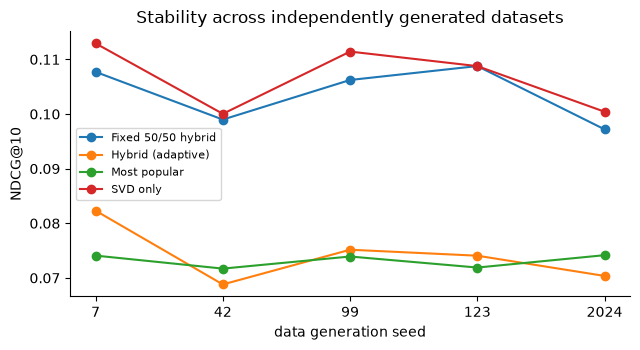

,mean,std,min,max
model,,,,
Fixed 50/50 hybrid,0.1038,0.0053,0.0972,0.1088
Hybrid (adaptive),0.0741,0.0053,0.0688,0.0823
Most popular,0.0732,0.0012,0.0717,0.0742
SVD only,0.1067,0.0061,0.1000,0.1129


In [21]:
seed_rows = []
for seed in [42, 7, 123, 2024, 99]:
    e, p = make_data(seed=seed)
    st = run_pipeline(e, p, k=12, n_full=8)
    for m in ["SVD only", "Fixed 50/50 hybrid", "Hybrid (adaptive)", "Most popular"]:
        seed_rows.append({"seed": seed, "model": m,
                          "ndcg@10": per_user_metrics(st["scores"][m], st, st["test"]).ndcg.mean()})
seeds = pd.DataFrame(seed_rows)
seed_pivot = seeds.pivot(index="seed", columns="model", values="ndcg@10")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for m in seed_pivot.columns:
    ax.plot(seed_pivot.index.astype(str), seed_pivot[m], marker="o", label=m)
ax.set_xlabel("data generation seed"); ax.set_ylabel("NDCG@10")
ax.set_title("Stability across independently generated datasets"); ax.legend(fontsize=8)
plt.tight_layout(); savefig("fig9_seed_stability"); plt.show()

seeds.groupby("model")["ndcg@10"].agg(["mean", "std", "min", "max"]).round(4)

SVD beats popularity on all five generated datasets, while the fixed blend also remains stronger than popularity. The difference between SVD and the fixed blend is small, so I treat the models as broadly similar in accuracy. Because all datasets came from the same generator, this supports stability but not generalisation to real customer behaviour.

### 6.4 Benchmark comparison

These comparisons are qualitative because the published studies use different datasets and evaluation methods.

| Source | Main finding | Result here |
| --- | --- | --- |
| Cremonesi et al. (2010) | Popularity is a strong top-N baseline. | SVD beats popularity. |
| Ferrari Dacrema et al. (2019) | Simple tuned models can be competitive. | SVD and the fixed blend perform best. |
| Abdollahpouri et al. (2017) | Accuracy can increase popularity bias. | SVD concentrates recommendations in the popular-item head. |
| Herlocker et al. (2004); McNee et al. (2006) | Accuracy alone is incomplete. | NDCG and coverage give different conclusions. |

The comparison supports the general interpretation of this project, but it does not prove that the synthetic data represents real retail behaviour.

### Expert review and limitations

No formal external expert review was completed. I validated the approach against published guidance by using a time-based split, baseline models, several evaluation metrics, and paired significance testing (Ferrari Dacrema, Cremonesi, & Jannach, 2019).

Each comparison is qualitative rather than a direct replication. The published studies use different datasets, train-test splits, candidate sets, and evaluation measures, so their numerical results cannot be compared directly with the values in this notebook. The comparisons are useful only for checking whether the general patterns are familiar in recommender-system research.

### Expert review and limitations

No formal external expert review was completed for this assignment. I instead checked the evaluation design against published recommender-system guidance: a time-based split, a test set not used for tuning, baseline models, several evaluation measures, and paired significance testing (Ferrari Dacrema, Cremonesi, & Jannach, 2019).

The main limitation is that all experiments use synthetic data generated by the same process. Repeating the experiment with different random seeds tests stability within that generator, but it does not show that the findings will hold for real customer behaviour. The results should therefore be treated as a useful prototype analysis, not as evidence that the same model should be deployed without further testing.

## 7. Conclusion and recommendations

1. **Use the fixed 50/50 blend as the preferred prototype.** It has accuracy similar to SVD in this experiment, while covering more of the catalogue and relying less on the most popular products.
2. **Do not use the current adaptive formula without further work.** Its zero collaborative-filtering weight performs poorly for customers with very little history. A minimum collaborative weight should be tested on a validation set.
3. **Report several measures together.** NDCG@10 should be reported with catalogue coverage and the share of recommendations from the most popular products.
4. **Keep the privacy controls.** Pseudonymisation, integrity checks, data minimisation, and encrypted exports are appropriate safeguards for a future version that uses real customer data, but they do not replace a full privacy or security review.

Overall, the fixed blend is the most balanced result in this prototype. The conclusion is limited by the synthetic dataset and should be tested again with real, ethically governed data before deployment.

## References

Abdollahpouri, H., Burke, R., & Mobasher, B. (2017). Controlling popularity bias in learning-to-rank recommendation. *Proceedings of the 11th ACM Conference on Recommender Systems*, 42–46. https://doi.org/10.1145/3109859.3109912

Cremonesi, P., Koren, Y., & Turrin, R. (2010). Performance of recommender algorithms on top-N recommendation tasks. *Proceedings of the 4th ACM Conference on Recommender Systems*, 39–46. https://doi.org/10.1145/1864708.1864721

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall.

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters, 27*(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010

Ferrari Dacrema, M., Cremonesi, P., & Jannach, D. (2019). Are we really making much progress? A worrying analysis of recent neural recommendation approaches. *Proceedings of the 13th ACM Conference on Recommender Systems*, 101–109. https://doi.org/10.1145/3298689.3347058

Herlocker, J. L., Konstan, J. A., Terveen, L. G., & Riedl, J. T. (2004). Evaluating collaborative filtering recommender systems. *ACM Transactions on Information Systems, 22*(1), 5–53. https://doi.org/10.1145/963770.963772

McNee, S. M., Riedl, J., & Konstan, J. A. (2006). Being accurate is not enough: How accuracy metrics have hurt recommender systems. *CHI '06 Extended Abstracts on Human Factors in Computing Systems*, 1097–1101. https://doi.org/10.1145/1125451.1125659

Milano, S., Taddeo, M., & Floridi, L. (2020). Recommender systems and their ethical challenges. *AI & Society, 35*(4), 957–967. https://doi.org/10.1007/s00146-020-00950-y

Sharda, R., Delen, D., & Turban, E. (2020). *Analytics, data science, & artificial intelligence: Systems for decision support* (11th ed.). Pearson.

Voigt, P., & von dem Bussche, A. (2017). *The EU General Data Protection Regulation (GDPR): A practical guide*. Springer. https://doi.org/10.1007/978-3-319-57959-7